<div style="text-align:center; margin-top:60px;">

<p style="font-size:18px;">Universidad Tecnológica Nacional</p>
<p style="font-size:18px;">Facultad Regional Córdoba</p>

<hr style="width:45%; border:1px solid #003b71; margin-top:40px; margin-bottom:30px;">

<h1 style="color:#003b71;">Trabajo Integrador</h1>
<h2 style="color:#003b71;">Compensación por Adelanto</h2>
<h3 style="color:#0057a8;">Diseño por LGR con verificación en frecuencia</h3>

<hr style="width:45%; border:1px solid #003b71; margin-top:30px; margin-bottom:40px;">

<table style="margin-left:auto; margin-right:auto; font-size:16px;">
<tr><td><b>Materia:</b></td><td>Instrumentación y Control de Procesos</td></tr>
<tr><td><b>Carrera:</b></td><td>Lic. en Automatización y Control</td></tr>
<tr><td><b>Autor:</b></td><td>Gonzalo Vera</td></tr>
<tr><td><b>Fecha:</b></td><td>Mayo 2026</td></tr>
</table>

<br><br>

<p><b>Repositorio de referencia:</b></p>
<p>https://github.com/Automatizacion-y-Control/INT_Instrumentacion_y_Control_UTN.git</p>

</div>

# 1. Introducción y objetivos

El presente informe expone la resolución del Trabajo Integrador de la materia Instrumentación y Control de Procesos.  
El objetivo central consiste en compensar una planta dada mediante técnicas de control clásico, verificando que el sistema compensado cumpla con las especificaciones dinámicas y estacionarias indicadas en la consigna.

La planta bajo estudio es:

$$
G_p(s)=\frac{s+40}{s^3+60s^2+875s}
$$

equivalente a:

$$
G_p(s)=\frac{s+40}{s(s+25)(s+35)}
$$

Los requerimientos de diseño son:

$$
\zeta = 0.628
$$

$$
\omega_n = 21.324 \; rad/s
$$

$$
K_v = 3 \; rad/s
$$

El trabajo incluye:

- análisis de la planta original;
- cálculo de polos requeridos;
- diseño de compensador estándar;
- verificación de constante de error estacionario;
- simulación de respuesta al escalón antes y después de compensar;
- análisis complementario mediante LGR, Bode y seguimiento de rampa;
- discusión técnica sobre la interpretación del resultado.

# 2. Metodología y herramientas

Para resolver el trabajo se utilizaron herramientas informáticas basadas en Python:

- `NumPy`, para cálculo numérico y manipulación polinómica.
- `SciPy Signal`, para modelado de sistemas LTI y simulaciones temporales/frecuenciales.
- `Matplotlib`, para generación de gráficas.
- `SciPy Optimize`, para resolución numérica del sistema de ecuaciones asociado al diseño.

El procedimiento aplicado fue:

1. Modelado de la planta.
2. Factorización e identificación de polos y ceros.
3. Cálculo del par de polos requerido a partir de $$\zeta$$ y $$\omega_n$$.
4. Adopción de un compensador estándar de primer orden.
5. Resolución de parámetros del compensador imponiendo:
   - par complejo deseado;
   - constante de velocidad $$K_v=3$$.
6. Cierre de lazo con realimentación unitaria.
7. Validación mediante simulaciones y gráficas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import root
import math
import warnings

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

# 3. Planta original

La planta dada por la consigna es:

$$
G_p(s)=\frac{s+40}{s^3+60s^2+875s}
$$

Factorizando:

$$
s^3+60s^2+875s=s(s^2+60s+875)
$$

$$
s^2+60s+875=(s+25)(s+35)
$$

Por lo tanto:

$$
G_p(s)=\frac{s+40}{s(s+25)(s+35)}
$$

La planta posee:

- un polo en el origen;
- dos polos reales negativos;
- un cero real negativo.

In [2]:
num_p = np.array([1, 40], dtype=float)
den_p = np.array([1, 60, 875, 0], dtype=float)

Gp = signal.TransferFunction(num_p, den_p)

print("Planta Gp(s)")
print("Numerador:", num_p)
print("Denominador:", den_p)

print("\nPolos:")
print(np.roots(den_p))

print("\nCeros:")
print(np.roots(num_p))

Planta Gp(s)
Numerador: [ 1. 40.]
Denominador: [  1.  60. 875.   0.]

Polos:
[-35. -25.   0.]

Ceros:
[-40.]


# 4. Análisis dinámico de la planta

La planta tiene un integrador:

$$
p_1=0
$$

y dos polos rápidos:

$$
p_2=-25
$$

$$
p_3=-35
$$

Además posee un cero en:

$$
z_1=-40
$$

La presencia del integrador indica que el sistema es de tipo 1.  
Esto implica que, en lazo cerrado con realimentación unitaria, puede presentar error nulo ante una entrada escalón, pero error finito ante una entrada rampa.

La constante de error de velocidad de la planta sin ganancia adicional es:

$$
K_v=\lim_{s\to 0}sG_p(s)
$$

$$
K_v=\frac{40}{25\cdot35}
$$

In [3]:
Kv_planta = 40/(25*35)
print("Kv natural de la planta:", Kv_planta)
print("Error estacionario ante rampa sin ganancia:", 1/Kv_planta)

Kv natural de la planta: 0.045714285714285714
Error estacionario ante rampa sin ganancia: 21.875


# 5. Requerimientos de diseño

La consigna exige que la respuesta compensada tenga:

$$
\zeta = 0.628
$$

$$
\omega_n = 21.324 \; rad/s
$$

El par de polos asociado a estas especificaciones es:

$$
s_{d1,d2}
=
-\zeta\omega_n
\pm
j\omega_n\sqrt{1-\zeta^2}
$$

In [4]:
zeta = 0.628
wn = 21.324
Kv_req = 3

sigma = zeta * wn
wd = wn * math.sqrt(1 - zeta**2)

sd1 = -sigma + 1j*wd
sd2 = -sigma - 1j*wd

print("sigma =", sigma)
print("wd =", wd)
print("Polo deseado 1:", sd1)
print("Polo deseado 2:", sd2)

desired_second_order = np.array([1, 2*zeta*wn, wn**2])
print("\nPolinomio de segundo orden deseado:")
print(desired_second_order)

sigma = 13.391472
wd = 16.59462122716924
Polo deseado 1: (-13.391472+16.59462122716924j)
Polo deseado 2: (-13.391472-16.59462122716924j)

Polinomio de segundo orden deseado:
[  1.        26.782944 454.712976]


# 6. Modelo estándar del compensador

Se adopta un compensador estándar de primer orden:

$$
G_c(s)=K_c\frac{s+a}{s+b}
$$

El lazo abierto compensado queda:

$$
G_{OL}(s)=G_c(s)G_p(s)
$$

$$
G_{OL}(s)=
K_c\frac{s+a}{s+b}
\frac{s+40}{s(s+25)(s+35)}
$$

La ecuación característica del sistema compensado con realimentación unitaria es:

$$
1+G_{OL}(s)=0
$$

Por lo tanto:

$$
(s+b)s(s+25)(s+35)+K_c(s+a)(s+40)=0
$$

Los parámetros $$K_c$$, $$a$$ y $$b$$ se calculan imponiendo el par de polos requerido y la constante $$K_v=3$$.

# 7. Cálculo del compensador

Como el compensador agrega un polo, el sistema compensado queda de cuarto orden.

Se impone que el polinomio característico contenga el par complejo deseado:

$$
s^2+2\zeta\omega_n s+\omega_n^2
$$

y dos polos reales adicionales:

$$
(s+q)(s+r)
$$

El polinomio deseado queda:

$$
(s^2+2\zeta\omega_n s+\omega_n^2)(s+q)(s+r)
$$

Además, se exige:

$$
K_v=3
$$

Para el sistema compensado:

$$
K_v=
K_c
\frac{a}{b}
\frac{40}{875}
$$

In [5]:
A = 2*zeta*wn
B = wn**2

def equations_design(vars):
    Kc, a, b, q, r = vars

    actual = np.array([
        60 + b,
        875 + 60*b + Kc,
        875*b + Kc*(a + 40),
        40*Kc*a
    ], dtype=float)

    desired_poly = np.polymul([1, A, B], [1, q+r, q*r])
    desired = desired_poly[1:]

    kv_eq = 40*Kc*a/(875*b) - Kv_req

    return np.r_[actual - desired, kv_eq]

guess = [300, 1, 5, 40, 1]
sol = root(equations_design, guess)

Kc, a, b, q, r = sol.x

print("Convergencia:", sol.success)
print("Kc =", Kc)
print("a  =", a)
print("b  =", b)
print("q  =", q)
print("r  =", r)

print("\nError de ecuaciones:")
print(equations_design(sol.x))

num_c = np.array([Kc, Kc*a])
den_c = np.array([1, b])

print("\nCompensador obtenido:")
print(f"Gc(s) = {Kc:.6f} (s + {a:.6f}) / (s + {b:.6f})")

Convergencia: True
Kc = 337.9444089666162
a  = 0.9298915092201235
b  = 4.788596365509148
q  = 37.263807728764554
r  = 0.7418446367445919

Error de ecuaciones:
[ 0.00000000e+00  2.27373675e-13 -3.63797881e-11 -1.48611434e-09
 -6.53699317e-13]

Compensador obtenido:
Gc(s) = 337.944409 (s + 0.929892) / (s + 4.788596)


# 8. Clasificación del compensador

El compensador obtenido tiene la forma:

$$
G_c(s)=K_c\frac{s+a}{s+b}
$$

con:

$$
a=0.9299
$$

$$
b=4.7886
$$

Como:

$$
a<b
$$

el cero se encuentra más cerca del origen que el polo.  
Por lo tanto, el compensador corresponde a una red de adelanto.

Este tipo de compensador aporta fase positiva y permite modificar el Lugar Geométrico de las Raíces para alcanzar la ubicación deseada de polos.

In [6]:
print("Cero del compensador:", np.roots(num_c))
print("Polo del compensador:", np.roots(den_c))

Cero del compensador: [-0.92989151]
Polo del compensador: [-4.78859637]


# 9. Sistema sin compensar y sistema compensado

Para la comparación se analiza:

1. Sistema sin compensador dinámico, ajustado con ganancia proporcional para cumplir $$K_v=3$$.
2. Sistema compensado con la red de adelanto obtenida.

La ganancia proporcional necesaria para que la planta sin compensador dinámico cumpla $$K_v=3$$ es:

$$
K=\frac{3}{K_{v,p}}
$$

In [7]:
K_prop = Kv_req / Kv_planta
print("Ganancia proporcional para Kv=3:", K_prop)

def closed_loop_tf(num_ol, den_ol):
    den_cl = np.polyadd(den_ol, num_ol)
    num_cl = num_ol
    return signal.TransferFunction(num_cl, den_cl), num_cl, den_cl

# Sin compensador dinámico
num_ol_prop = K_prop * num_p
den_ol_prop = den_p
T_prop, num_cl_prop, den_cl_prop = closed_loop_tf(num_ol_prop, den_ol_prop)

# Compensado
num_ol_comp = np.polymul(num_c, num_p)
den_ol_comp = np.polymul(den_c, den_p)
T_comp, num_cl_comp, den_cl_comp = closed_loop_tf(num_ol_comp, den_ol_comp)

print("\nPolos sin compensador dinámico:")
print(np.roots(den_cl_prop))

print("\nPolos compensados:")
poles_comp = np.roots(den_cl_comp)
print(poles_comp)

Ganancia proporcional para Kv=3: 65.625

Polos sin compensador dinámico:
[-35.73072311 -20.72435688  -3.54492001]

Polos compensados:
[-37.26380773 +0.j         -13.391472  +16.59462123j
 -13.391472  -16.59462123j  -0.74184464 +0.j        ]


# 10. Verificación de especificaciones

Se verifica que el sistema compensado contiene el par complejo requerido y que cumple la constante de velocidad solicitada.

In [8]:
complex_poles = [p for p in poles_comp if abs(np.imag(p)) > 1e-6]

p = complex_poles[0]
wn_obt = abs(p)
zeta_obt = -np.real(p)/wn_obt
wd_obt = abs(np.imag(p))

Kv_comp = Kc*(a/b)*40/875
Kv_prop = K_prop*40/875

print("Polos deseados:")
print(sd1)
print(sd2)

print("\nPar complejo obtenido:")
print(complex_poles)

print("\nzeta obtenido:", zeta_obt)
print("wn obtenido:", wn_obt)
print("wd obtenido:", wd_obt)

print("\nKv sin compensador dinámico:", Kv_prop)
print("Kv compensado:", Kv_comp)

Polos deseados:
(-13.391472+16.59462122716924j)
(-13.391472-16.59462122716924j)

Par complejo obtenido:
[np.complex128(-13.39147200000004+16.594621227169267j), np.complex128(-13.39147200000004-16.594621227169267j)]

zeta obtenido: 0.6280000000000006
wn obtenido: 21.324000000000044
wd obtenido: 16.594621227169267

Kv sin compensador dinámico: 3.0
Kv compensado: 2.9999999999993463


# 11. Respuesta al escalón

La consigna solicita explícitamente simular la respuesta al escalón del sistema antes y después de la compensación.

Se compara:

- sistema sin compensador dinámico;
- sistema compensado.

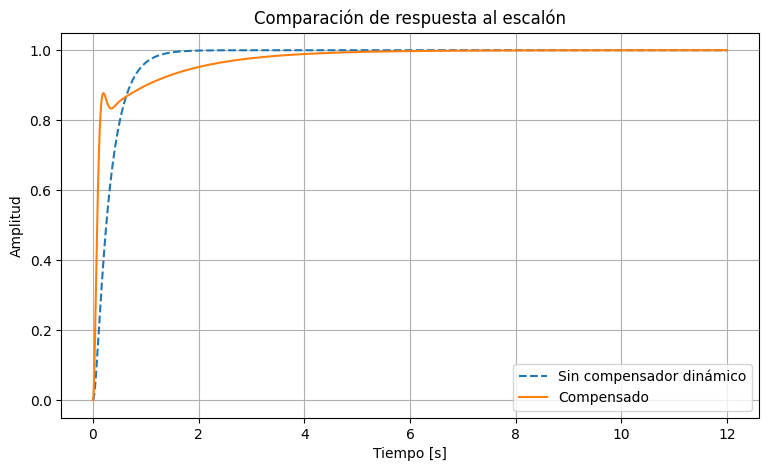

Indicadores sin compensador dinámico:
{'valor_final': np.float64(0.9999999999999958), 'sobrepico_%': np.float64(1.1102230246251613e-14), 'tiempo_subida_10_90': np.float64(0.6362120706902301), 'tiempo_establecimiento_2%': np.float64(1.160386795598533)}

Indicadores compensados:
{'valor_final': np.float64(0.9999712165501787), 'sobrepico_%': 0, 'tiempo_subida_10_90': np.float64(0.98432810936979), 'tiempo_establecimiento_2%': np.float64(3.1810603534511506)}


In [9]:
def step_info(t, y, tol=0.02):
    y = np.asarray(y)
    t = np.asarray(t)
    yf = y[-1]
    yp = np.max(y)
    Mp = np.nan if abs(yf) < 1e-12 else max(0, (yp-yf)/abs(yf)*100)

    band = tol*max(abs(yf), 1e-12)
    outside = np.where(np.abs(y-yf) > band)[0]
    ts = t[outside[-1]+1] if len(outside) and outside[-1]+1 < len(t) else t[0]

    def first_cross(level):
        idx = np.where(y >= level)[0]
        return t[idx[0]] if len(idx) else np.nan

    tr = first_cross(0.9*yf) - first_cross(0.1*yf)

    return {
        "valor_final": yf,
        "sobrepico_%": Mp,
        "tiempo_subida_10_90": tr,
        "tiempo_establecimiento_2%": ts
    }

t = np.linspace(0, 12, 3000)

t1, y1 = signal.step(T_prop, T=t)
t2, y2 = signal.step(T_comp, T=t)

plt.figure()
plt.plot(t1, y1, "--", label="Sin compensador dinámico")
plt.plot(t2, y2, label="Compensado")
plt.title("Comparación de respuesta al escalón")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.legend()
plt.show()

print("Indicadores sin compensador dinámico:")
print(step_info(t1, y1))

print("\nIndicadores compensados:")
print(step_info(t2, y2))

# 12. Lugar Geométrico de las Raíces

El compensador modifica el LGR agregando un cero y un polo.  
Esto permite que el lugar geométrico pase por la zona asociada al par complejo especificado.

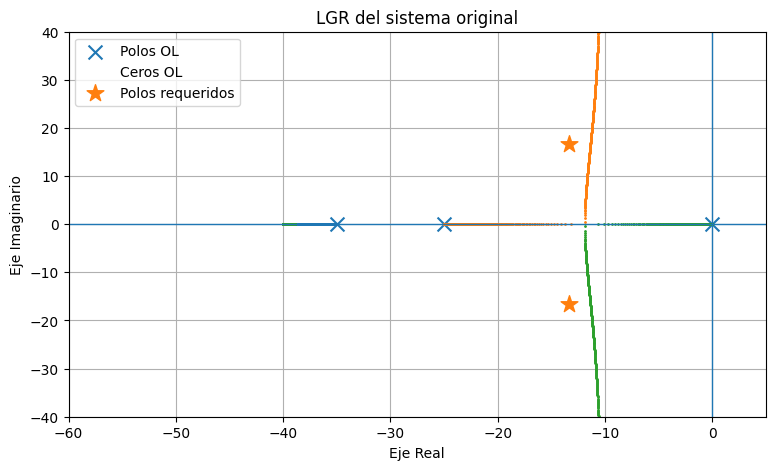

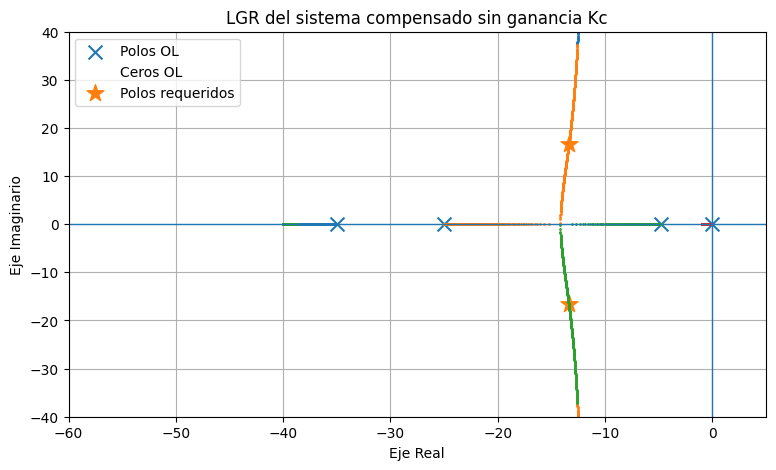

In [10]:
def root_locus(num, den, title):
    k_values = np.logspace(-3, 5, 1600)
    roots = []

    for K in k_values:
        roots.append(np.roots(np.polyadd(den, K*num)))

    roots = np.array(roots)

    plt.figure()
    for i in range(roots.shape[1]):
        plt.plot(np.real(roots[:, i]), np.imag(roots[:, i]), ".", markersize=2)

    poles = np.roots(den)
    zeros = np.roots(num)

    plt.scatter(np.real(poles), np.imag(poles), marker="x", s=100, label="Polos OL")
    plt.scatter(np.real(zeros), np.imag(zeros), marker="o", facecolors="none", s=100, label="Ceros OL")
    plt.scatter([np.real(sd1), np.real(sd2)], [np.imag(sd1), np.imag(sd2)], marker="*", s=160, label="Polos requeridos")

    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.title(title)
    plt.xlabel("Eje Real")
    plt.ylabel("Eje Imaginario")
    plt.xlim(-60, 5)
    plt.ylim(-40, 40)
    plt.legend()
    plt.show()

root_locus(num_p, den_p, "LGR del sistema original")
root_locus(num_ol_comp/Kc, den_ol_comp, "LGR del sistema compensado sin ganancia Kc")

# 13. Análisis en frecuencia

Aunque el diseño principal se realiza en función de polos y constante de error, se analiza también el comportamiento frecuencial mediante Bode.

Esto permite observar el efecto del compensador sobre la ganancia y la fase.

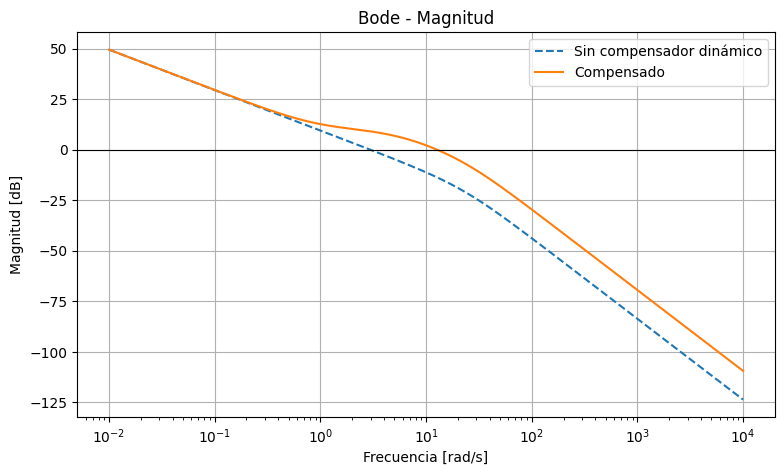

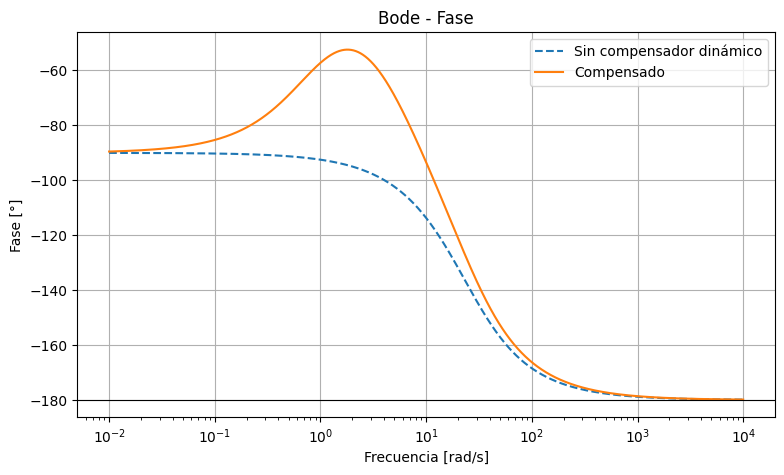

In [11]:
w = np.logspace(-2, 4, 3000)

def bode_data(num, den):
    sys = signal.TransferFunction(num, den)
    return signal.bode(sys, w=w)

w0, mag0, phase0 = bode_data(num_ol_prop, den_ol_prop)
w1, mag1, phase1 = bode_data(num_ol_comp, den_ol_comp)

plt.figure()
plt.semilogx(w0, mag0, "--", label="Sin compensador dinámico")
plt.semilogx(w1, mag1, label="Compensado")
plt.axhline(0, color="k", linewidth=0.8)
plt.title("Bode - Magnitud")
plt.xlabel("Frecuencia [rad/s]")
plt.ylabel("Magnitud [dB]")
plt.legend()
plt.show()

plt.figure()
plt.semilogx(w0, phase0, "--", label="Sin compensador dinámico")
plt.semilogx(w1, phase1, label="Compensado")
plt.axhline(-180, color="k", linewidth=0.8)
plt.title("Bode - Fase")
plt.xlabel("Frecuencia [rad/s]")
plt.ylabel("Fase [°]")
plt.legend()
plt.show()

# 14. Respuesta ante rampa

El requisito $$K_v=3$$ está asociado al seguimiento de una entrada rampa.

Para un sistema tipo 1 con realimentación unitaria:

$$
e_{ss,rampa}=\frac{1}{K_v}
$$

Por lo tanto, si:

$$
K_v=3
$$

se espera:

$$
e_{ss,rampa}=\frac{1}{3}=0.3333
$$

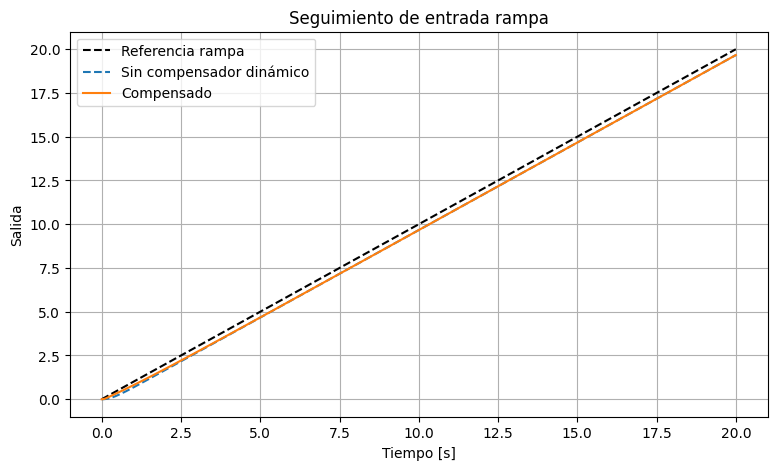

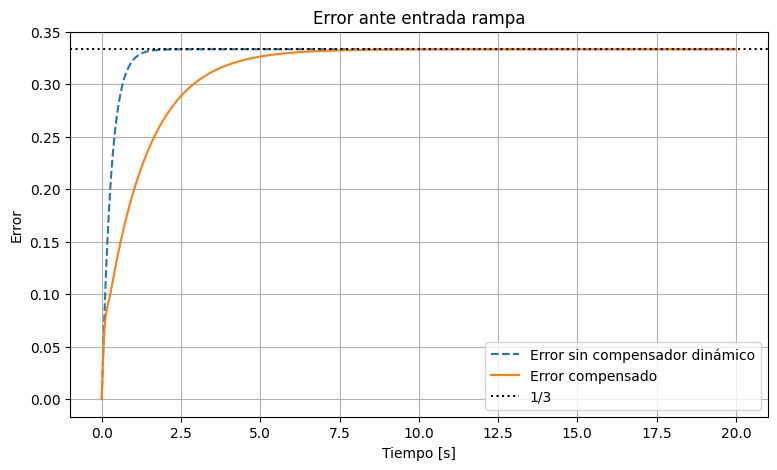

Error final sin compensador dinámico: 0.3333333333333286
Error final compensado: 0.3333332306742207


In [12]:
def simulate_response(sys, t, u):
    tout, y, x = signal.lsim(sys, U=u, T=t)
    return y

t_r = np.linspace(0, 20, 4000)
r = t_r

y_prop = simulate_response(T_prop, t_r, r)
y_comp = simulate_response(T_comp, t_r, r)

e_prop = r - y_prop
e_comp = r - y_comp

plt.figure()
plt.plot(t_r, r, "k--", label="Referencia rampa")
plt.plot(t_r, y_prop, "--", label="Sin compensador dinámico")
plt.plot(t_r, y_comp, label="Compensado")
plt.title("Seguimiento de entrada rampa")
plt.xlabel("Tiempo [s]")
plt.ylabel("Salida")
plt.legend()
plt.show()

plt.figure()
plt.plot(t_r, e_prop, "--", label="Error sin compensador dinámico")
plt.plot(t_r, e_comp, label="Error compensado")
plt.axhline(1/3, color="k", linestyle=":", label="1/3")
plt.title("Error ante entrada rampa")
plt.xlabel("Tiempo [s]")
plt.ylabel("Error")
plt.legend()
plt.show()

print("Error final sin compensador dinámico:", e_prop[-1])
print("Error final compensado:", e_comp[-1])

# 15. Discusión técnica

El compensador obtenido satisface formalmente los requerimientos de la consigna:

$$
\zeta=0.628
$$

$$
\omega_n=21.324 \; rad/s
$$

$$
K_v=3
$$

No obstante, al tratarse de un sistema de orden superior, el par complejo especificado no describe por sí solo toda la dinámica del sistema.

El sistema compensado contiene además polos reales. En particular, aparece un polo real más cercano al origen que el par complejo especificado. Esto implica que la respuesta temporal completa no debe interpretarse únicamente como una respuesta de segundo orden dominante.

Esta observación no invalida el diseño, pero sí obliga a interpretar con cuidado la simulación.

# 16. Conclusiones

A partir del desarrollo realizado se concluye:

1. La planta original es un sistema de tipo 1, con un integrador en el origen, dos polos reales estables y un cero real negativo.

2. La constante natural de velocidad de la planta es baja:

$$
K_v=0.0457
$$

por lo que la planta sin ajuste presenta error elevado ante entrada rampa.

3. Para cumplir el requisito:

$$
K_v=3
$$

es necesario aumentar la ganancia efectiva de baja frecuencia.

4. El compensador estándar diseñado fue:

$$
G_c(s)=337.9444\frac{s+0.9299}{s+4.7886}
$$

5. Dado que el cero se encuentra más cerca del origen que el polo, el compensador corresponde a una red de adelanto.

6. El sistema compensado verifica el par complejo asociado a las especificaciones solicitadas y cumple la constante de velocidad requerida.

7. La respuesta al escalón fue simulada antes y después de la compensación, cumpliendo con la exigencia del trabajo.

8. La respuesta ante rampa confirma la relación directa entre el requerimiento de $$K_v$$ y el error estacionario de velocidad.

9. La presencia de polos adicionales muestra que el comportamiento real del sistema no debe interpretarse únicamente desde el modelo de segundo orden asociado a $$\zeta$$ y $$\omega_n$$.

En síntesis, el compensador obtenido cumple la consigna, pero el análisis completo evidencia la importancia de validar el sistema mediante simulación y no solamente mediante el cumplimiento algebraico de especificaciones.

# 17. Referencias

[1] Ogata, K. — Ingeniería de Control Moderna, 5ta edición, Pearson.  
[2] Dorf, R. C. & Bishop, R. H. — Sistemas de Control Moderno, 13va edición, Pearson.  
[3] MathWorks — Control System Toolbox Documentation.  
[4] Material de cátedra — Instrumentación y Control de Procesos, UTN FRC.

# 18. Resumen numérico final

In [13]:
print("RESUMEN FINAL")
print("=============")

print("\nPlanta:")
print("Gp(s) = (s + 40) / (s^3 + 60s^2 + 875s)")
print("Gp(s) = (s + 40) / [s(s + 25)(s + 35)]")

print("\nRequerimientos:")
print("zeta =", zeta)
print("wn   =", wn)
print("Kv   =", Kv_req)

print("\nCompensador:")
print(f"Gc(s) = {Kc:.6f} (s + {a:.6f}) / (s + {b:.6f})")

print("\nPolos compensados:")
for pole in poles_comp:
    print(pole)

print("\nVerificación:")
print("zeta obtenido =", zeta_obt)
print("wn obtenido   =", wn_obt)
print("Kv compensado =", Kv_comp)

RESUMEN FINAL

Planta:
Gp(s) = (s + 40) / (s^3 + 60s^2 + 875s)
Gp(s) = (s + 40) / [s(s + 25)(s + 35)]

Requerimientos:
zeta = 0.628
wn   = 21.324
Kv   = 3

Compensador:
Gc(s) = 337.944409 (s + 0.929892) / (s + 4.788596)

Polos compensados:
(-37.263807728764576+0j)
(-13.39147200000004+16.594621227169267j)
(-13.39147200000004-16.594621227169267j)
(-0.7418446367445001+0j)

Verificación:
zeta obtenido = 0.6280000000000006
wn obtenido   = 21.324000000000044
Kv compensado = 2.9999999999993463
